# IMC Prosperity — Round 2 Data Analysis

Products: **INTARIAN_PEPPER_ROOT (IPR)** and **ASH_COATED_OSMIUM (ACO)**  
Data: 3 days (day -1, 0, 1) of price snapshots and XIRECS market trades  
Goal: Characterise both markets, understand XIRECS trade patterns, and surface strategy insights for round 2.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 5)})

DAYS = [-1, 0, 1]
BASE_PATH = './'  # adjust if running from a different directory

# ── Load all price data ──────────────────────────────────────────────────────
price_frames = []
for d in DAYS:
    df = pd.read_csv(f'{BASE_PATH}prices_round_2_day_{d}.csv', sep=';')
    df['day'] = d
    price_frames.append(df)
prices = pd.concat(price_frames, ignore_index=True)

# Compute spread and global tick (timestamp within the full 3-day window)
prices['spread'] = prices['ask_price_1'] - prices['bid_price_1']
prices['global_ts'] = (prices['day'] + 1) * 1_000_000 + prices['timestamp']

# ── Load all trade data ──────────────────────────────────────────────────────
trade_frames = []
for d in DAYS:
    df = pd.read_csv(f'{BASE_PATH}trades_round_2_day_{d}.csv', sep=';')
    df['day'] = d
    trade_frames.append(df)
trades = pd.concat(trade_frames, ignore_index=True)
trades['global_ts'] = (trades['day'] + 1) * 1_000_000 + trades['timestamp']

ipr_prices = prices[prices['product'] == 'INTARIAN_PEPPER_ROOT'].copy()
aco_prices = prices[prices['product'] == 'ASH_COATED_OSMIUM'].copy()
ipr_trades = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT'].copy()
aco_trades = trades[trades['symbol'] == 'ASH_COATED_OSMIUM'].copy()

print(f'Price rows: {len(prices):,}  |  Trade rows: {len(trades):,}')
print(f'IPR price rows: {len(ipr_prices):,}  |  ACO price rows: {len(aco_prices):,}')
print(f'IPR XIRECS trades: {len(ipr_trades):,}  |  ACO XIRECS trades: {len(aco_trades):,}')

Price rows: 60,000  |  Trade rows: 2,391
IPR price rows: 30,000  |  ACO price rows: 30,000
IPR XIRECS trades: 996  |  ACO XIRECS trades: 1,395


## 1  Mid-Price Overview — All 3 Days

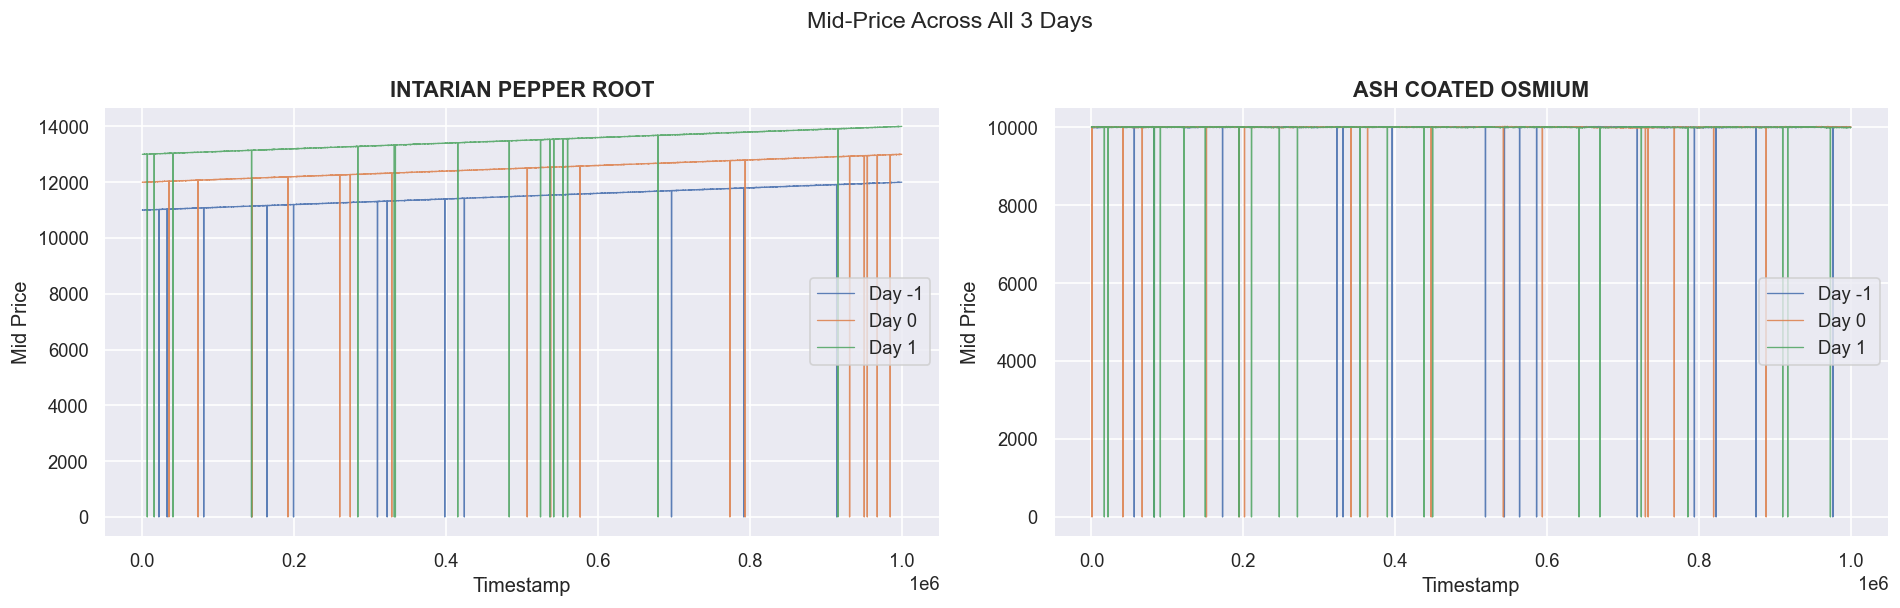

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = {-1: '#4C72B0', 0: '#DD8452', 1: '#55A868'}

for ax, (prod, df_prod) in zip(axes, [('INTARIAN_PEPPER_ROOT', ipr_prices), ('ASH_COATED_OSMIUM', aco_prices)]):
    for d in DAYS:
        sub = df_prod[df_prod['day'] == d]
        ax.plot(sub['timestamp'], sub['mid_price'], color=colors[d],
                linewidth=0.8, label=f'Day {d}', alpha=0.9)
    ax.set_title(prod.replace('_', ' '), fontsize=13, fontweight='bold')
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Mid Price')
    ax.legend()

plt.suptitle('Mid-Price Across All 3 Days', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2  IPR: Linear Trend Analysis

IPR exhibits a **perfect linear uptrend** within each day and across days. This is the most important insight for round 2: the fair value is entirely predictable.

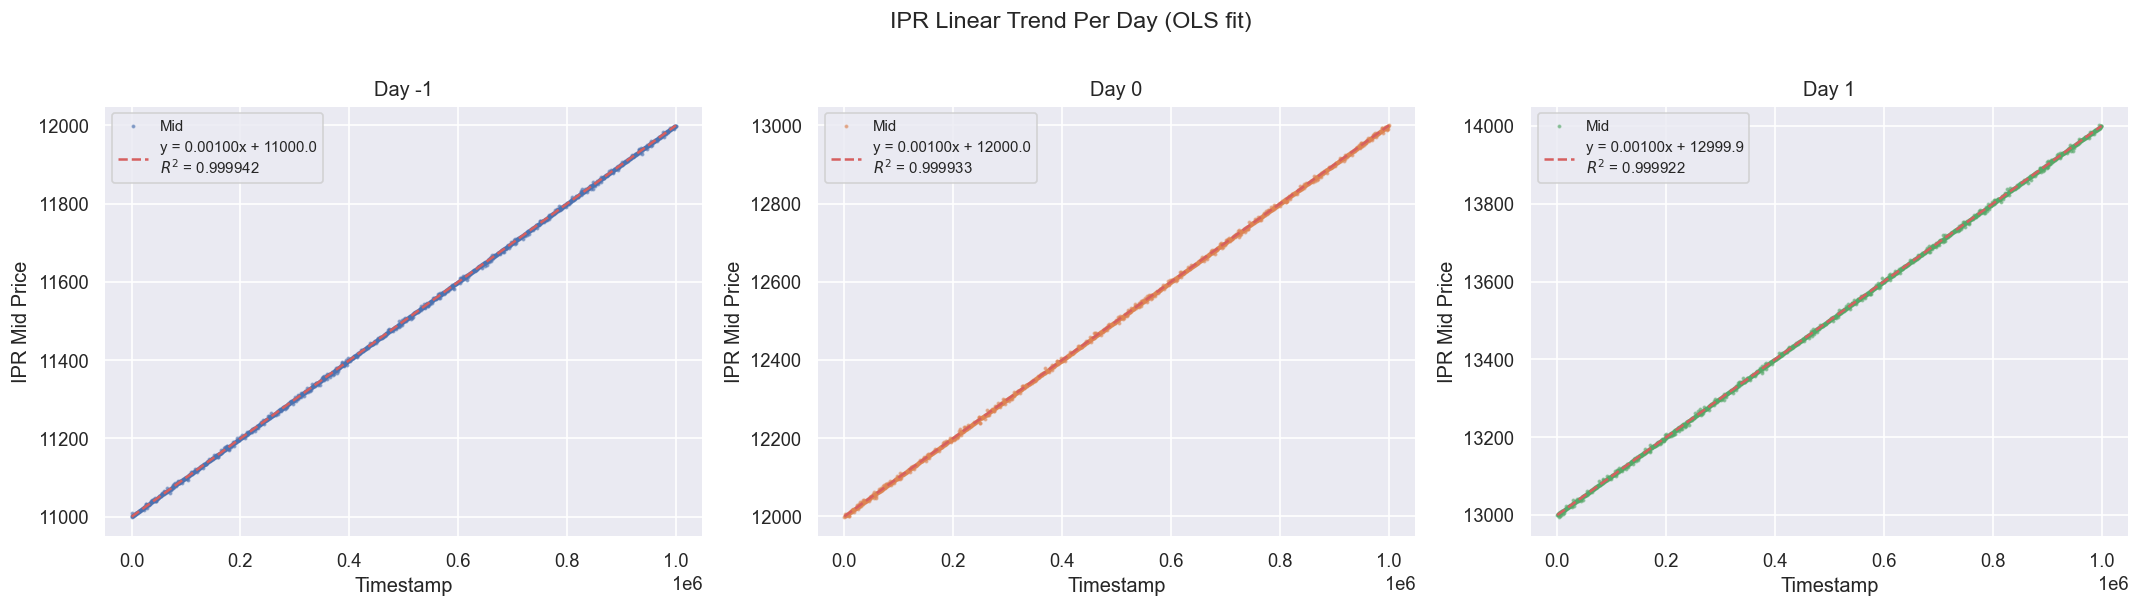


IPR OLS Summary:
Day    Slope/tick     Slope/1k ticks     Intercept      R²
-1     0.001000       1.0000             11000.0        0.99994220
0      0.001000       1.0000             12000.0        0.99993290
1      0.001000       1.0000             12999.9        0.99992245


In [4]:
# Fit OLS per day
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
slope_per_day = {}

for ax, d in zip(axes, DAYS):
    sub = ipr_prices[(ipr_prices['day'] == d) & (ipr_prices['mid_price'] > 0)]
    x = sub['timestamp'].values
    y = sub['mid_price'].values
    slope, intercept, r, p, se = stats.linregress(x, y)
    slope_per_day[d] = (slope, intercept, r**2)
    
    ax.scatter(x[::5], y[::5], s=2, alpha=0.5, color=colors[d], label='Mid')
    ax.plot(x, slope*x + intercept, 'r--', linewidth=1.5,
            label=f'y = {slope:.5f}x + {intercept:.1f}\n$R^2$ = {r**2:.6f}')
    ax.set_title(f'Day {d}', fontsize=12)
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('IPR Mid Price')
    ax.legend(fontsize=9)

plt.suptitle('IPR Linear Trend Per Day (OLS fit)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\nIPR OLS Summary:')
print(f'{"Day":<6} {"Slope/tick":<14} {"Slope/1k ticks":<18} {"Intercept":<14} {"R²"}')
for d, (s, ic, r2) in slope_per_day.items():
    print(f'{d:<6} {s:<14.6f} {s*1000:<18.4f} {ic:<14.1f} {r2:.8f}')

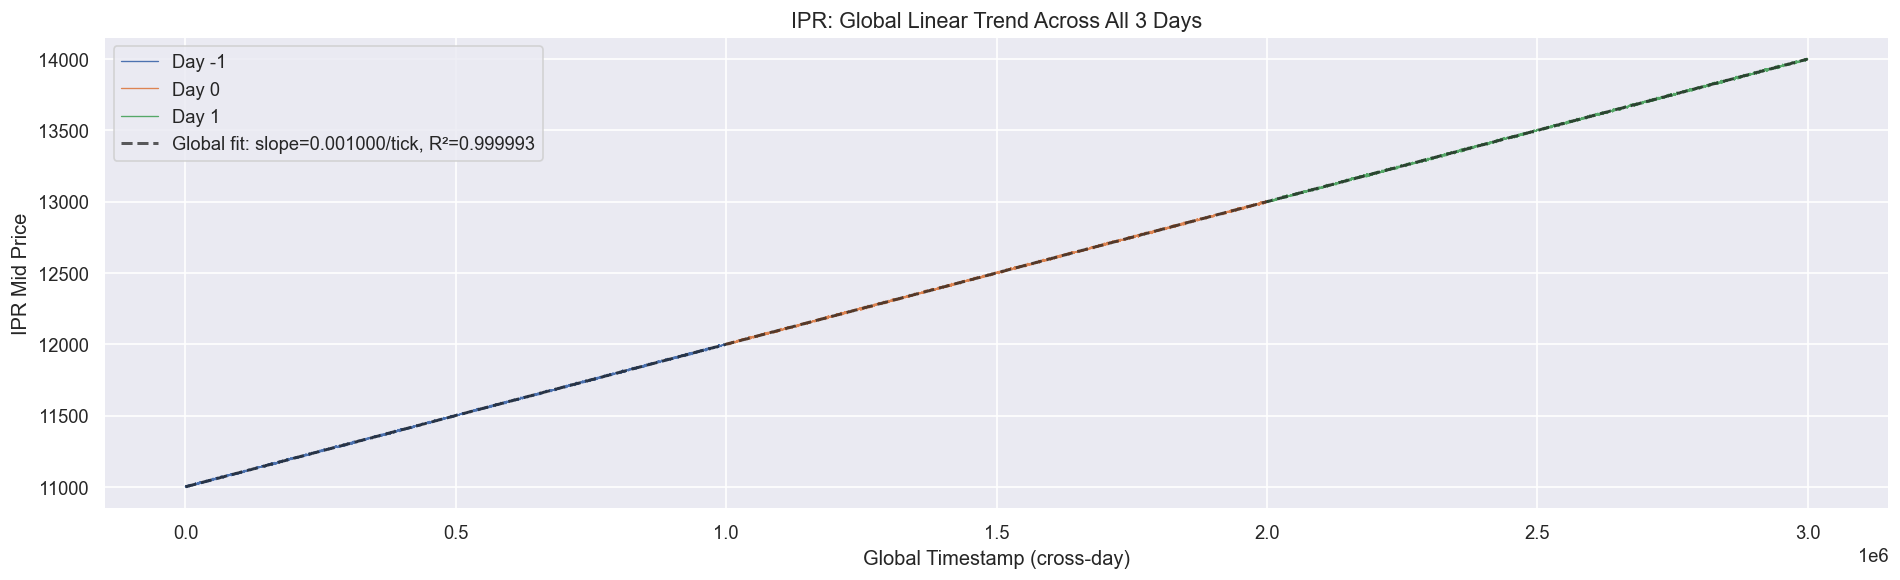


Global slope: 0.001000/tick (1.0000 per 1k ticks)
Day -1 start price: 11000.0
Prediction for Day 2, t=0: 14000.0
Prediction for Day 2, t=1M: 14999.9


In [5]:
# Show the cross-day pattern: starting price rises by +1000 per day
fig, ax = plt.subplots(figsize=(16, 5))

for d in DAYS:
    sub = ipr_prices[(ipr_prices['day'] == d) & (ipr_prices['mid_price'] > 0)]
    ax.plot(sub['global_ts'], sub['mid_price'], color=colors[d], linewidth=0.8, label=f'Day {d}')

# Overlay global linear fit
ipr_valid = ipr_prices[ipr_prices['mid_price'] > 0]
s_g, ic_g, r_g, _, _ = stats.linregress(ipr_valid['global_ts'], ipr_valid['mid_price'])
xs = ipr_valid['global_ts'].values
ax.plot(xs, s_g*xs + ic_g, 'k--', linewidth=1.8, alpha=0.7, label=f'Global fit: slope={s_g:.6f}/tick, R²={r_g**2:.6f}')

ax.set_xlabel('Global Timestamp (cross-day)')
ax.set_ylabel('IPR Mid Price')
ax.set_title('IPR: Global Linear Trend Across All 3 Days', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nGlobal slope: {s_g:.6f}/tick ({s_g*1000:.4f} per 1k ticks)')
print(f'Day -1 start price: {ic_g:.1f}')
print(f'Prediction for Day 2, t=0: {ic_g + s_g*3_000_000:.1f}')
print(f'Prediction for Day 2, t=1M: {ic_g + s_g*4_000_000:.1f}')

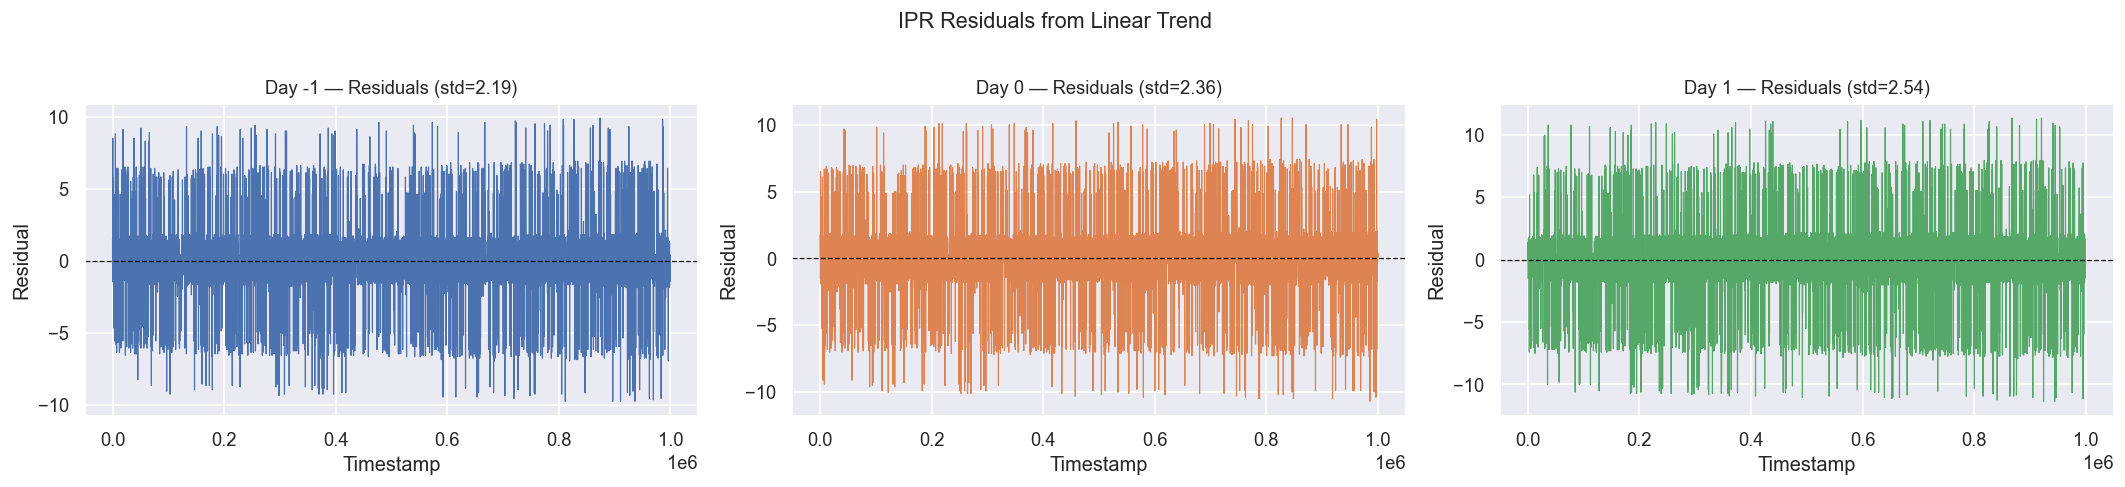

In [6]:
# IPR residuals from the linear model
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, d in zip(axes, DAYS):
    sub = ipr_prices[(ipr_prices['day'] == d) & (ipr_prices['mid_price'] > 0)].copy()
    s, ic, _, _, _ = stats.linregress(sub['timestamp'], sub['mid_price'])
    sub['fitted'] = s * sub['timestamp'] + ic
    sub['resid'] = sub['mid_price'] - sub['fitted']
    ax.plot(sub['timestamp'], sub['resid'], color=colors[d], linewidth=0.7)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.set_title(f'Day {d} — Residuals (std={sub["resid"].std():.2f})', fontsize=11)
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Residual')

plt.suptitle('IPR Residuals from Linear Trend', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3  ACO: Price Stability Analysis

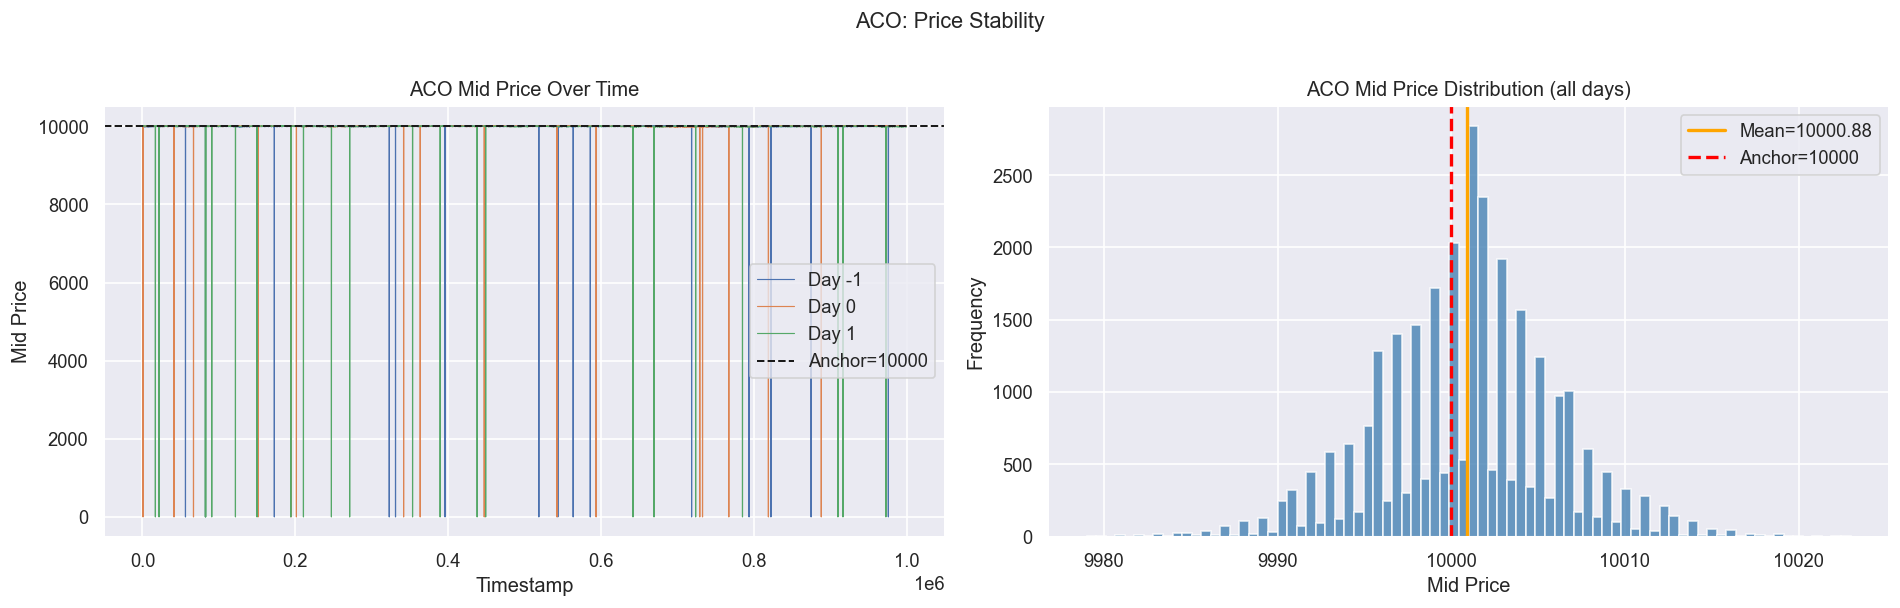

ACO Mid Price Statistics (all days):
count    29947.000000
mean     10000.879420
std          5.104032
min       9979.000000
25%       9998.000000
50%      10001.000000
75%      10004.000000
max      10023.000000

ACO mean distance from 10000: 4.01


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Time series of mid price
ax = axes[0]
for d in DAYS:
    sub = aco_prices[aco_prices['day'] == d]
    ax.plot(sub['timestamp'], sub['mid_price'], color=colors[d], linewidth=0.7, label=f'Day {d}')
ax.axhline(10000, color='k', linewidth=1.2, linestyle='--', label='Anchor=10000')
ax.set_title('ACO Mid Price Over Time', fontsize=12)
ax.set_xlabel('Timestamp')
ax.set_ylabel('Mid Price')
ax.legend()

# Distribution of mid price (all days combined)
ax = axes[1]
valid_aco = aco_prices[aco_prices['mid_price'] > 0]['mid_price']
ax.hist(valid_aco, bins=80, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(valid_aco.mean(), color='orange', linewidth=2, label=f'Mean={valid_aco.mean():.2f}')
ax.axvline(10000, color='red', linewidth=2, linestyle='--', label='Anchor=10000')
ax.set_title('ACO Mid Price Distribution (all days)', fontsize=12)
ax.set_xlabel('Mid Price')
ax.set_ylabel('Frequency')
ax.legend()

plt.suptitle('ACO: Price Stability', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('ACO Mid Price Statistics (all days):')
print(valid_aco.describe().to_string())
print(f'\nACO mean distance from 10000: {abs(valid_aco - 10000).mean():.2f}')

## 4  Spread Analysis (Both Products)

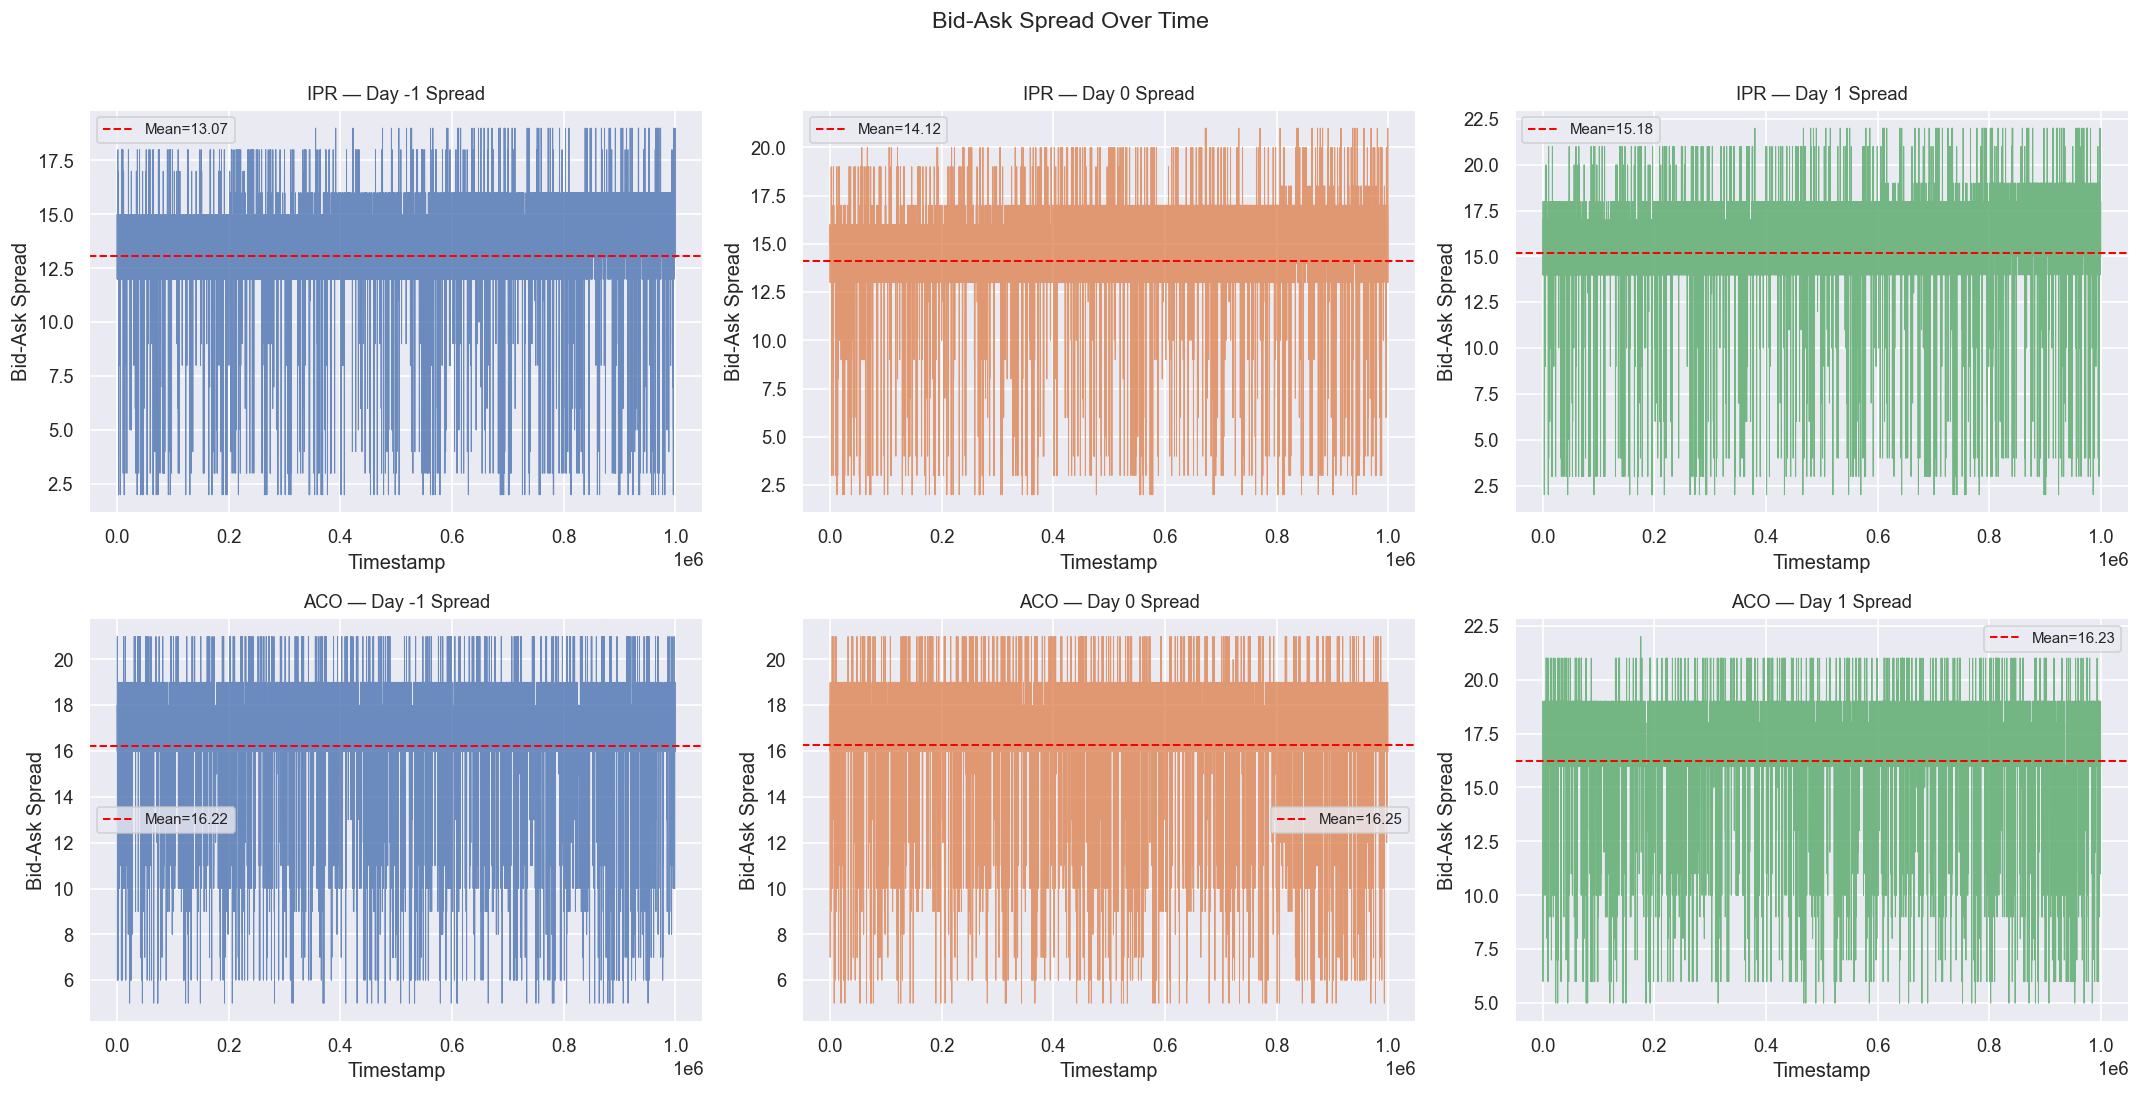

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for row, (prod_label, df_prod) in enumerate([('IPR', ipr_prices), ('ACO', aco_prices)]):
    for col, d in enumerate(DAYS):
        ax = axes[row, col]
        sub = df_prod[(df_prod['day'] == d) & df_prod['spread'].notna() & (df_prod['spread'] > 0)]
        
        # Time series of spread
        ax.plot(sub['timestamp'], sub['spread'], color=colors[d], linewidth=0.6, alpha=0.8)
        ax.axhline(sub['spread'].mean(), color='red', linewidth=1.2, linestyle='--',
                   label=f'Mean={sub["spread"].mean():.2f}')
        ax.set_title(f'{prod_label} — Day {d} Spread', fontsize=11)
        ax.set_xlabel('Timestamp')
        ax.set_ylabel('Bid-Ask Spread')
        ax.legend(fontsize=9)

plt.suptitle('Bid-Ask Spread Over Time', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

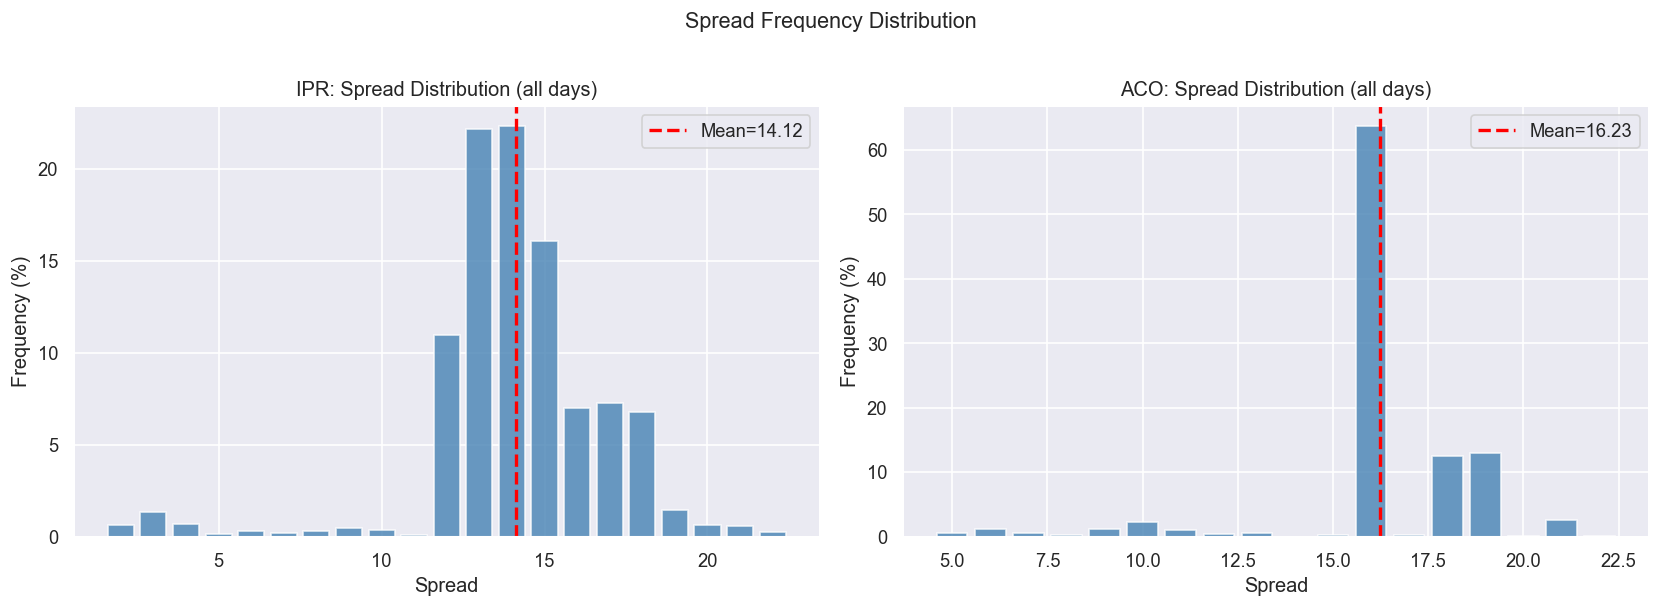


Metric                        IPR        ACO
Day -1 mean spread:          13.07      16.22
Day -1 spread std:            2.46       2.52
Day -1 tight (≤10):           4.6%       5.7%
Day 0 mean spread:          14.12      16.25
Day 0 spread std:            2.65       2.54
Day 0 tight (≤10):           4.5%       5.8%
Day 1 mean spread:          15.18      16.23
Day 1 spread std:            2.83       2.51
Day 1 tight (≤10):           4.2%       5.8%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (prod_label, df_prod) in zip(axes, [('IPR', ipr_prices), ('ACO', aco_prices)]):
    valid = df_prod[df_prod['spread'].notna() & (df_prod['spread'] > 0)]
    spread_vals = valid['spread'].values
    unique, counts = np.unique(spread_vals, return_counts=True)
    ax.bar(unique, counts / counts.sum() * 100, color='steelblue', alpha=0.8, edgecolor='white')
    ax.set_title(f'{prod_label}: Spread Distribution (all days)', fontsize=12)
    ax.set_xlabel('Spread')
    ax.set_ylabel('Frequency (%)')
    
    # Annotate mean
    ax.axvline(spread_vals.mean(), color='red', linewidth=2, linestyle='--',
               label=f'Mean={spread_vals.mean():.2f}')
    ax.legend()

plt.suptitle('Spread Frequency Distribution', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Summary table
print(f'\n{"Metric":<22} {"IPR":>10} {"ACO":>10}')
for d in DAYS:
    ipr_sub = ipr_prices[(ipr_prices['day'] == d) & (ipr_prices['spread'] > 0)]['spread']
    aco_sub = aco_prices[(aco_prices['day'] == d) & (aco_prices['spread'] > 0)]['spread']
    print(f'Day {d} mean spread:     {ipr_sub.mean():>10.2f} {aco_sub.mean():>10.2f}')
    print(f'Day {d} spread std:      {ipr_sub.std():>10.2f} {aco_sub.std():>10.2f}')
    print(f'Day {d} tight (≤10):     {(ipr_sub <= 10).mean()*100:>9.1f}% {(aco_sub <= 10).mean()*100:>9.1f}%')

## 5  XIRECS Trade Analysis

XIRECS trades represent the **external market** quotes. By paying an access fee in round 2, you unlock **25% more volume** from this source.

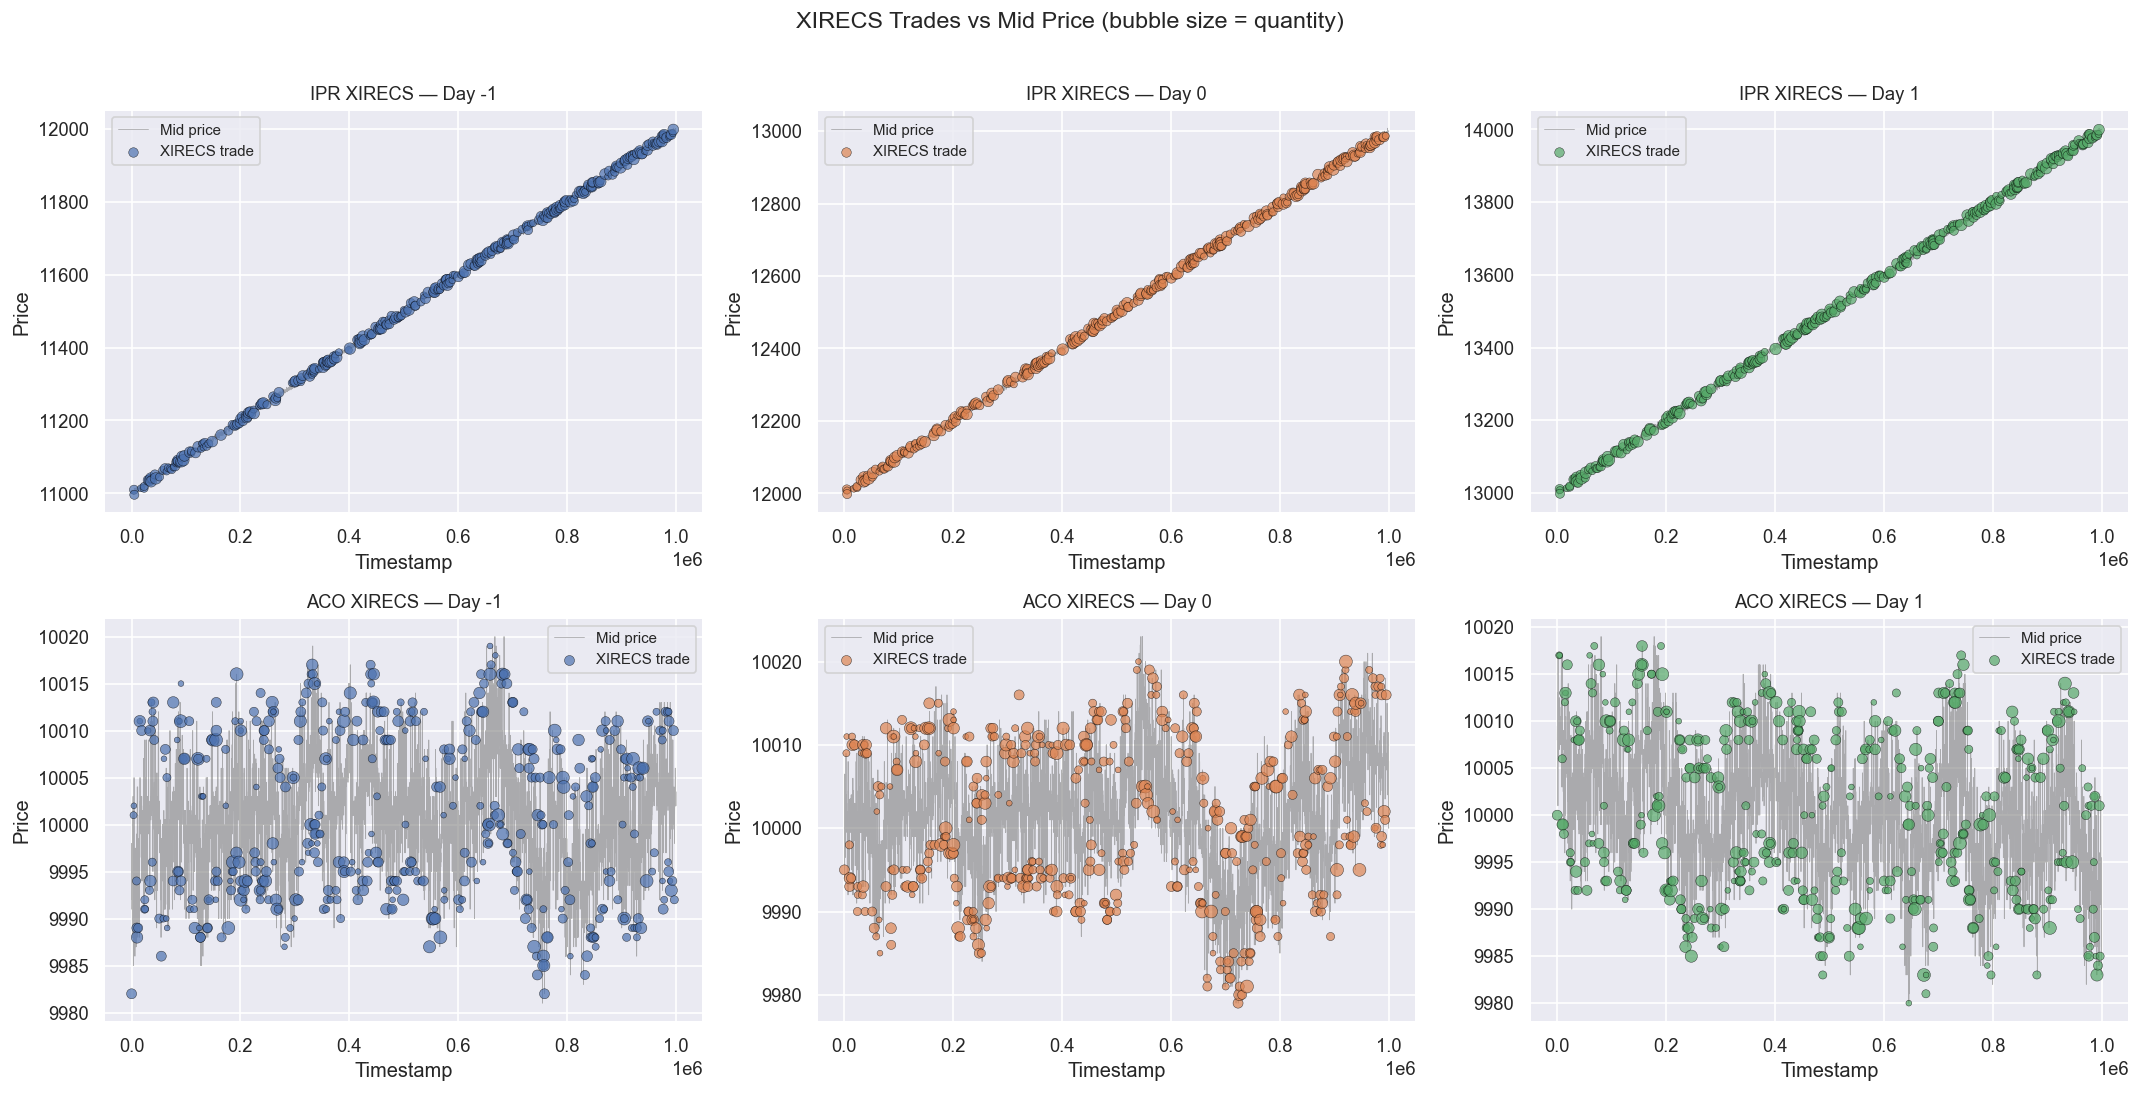

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for row, (prod_label, df_trd, df_prc) in enumerate([
    ('IPR XIRECS', ipr_trades, ipr_prices),
    ('ACO XIRECS', aco_trades, aco_prices)
]):
    for col, d in enumerate(DAYS):
        ax = axes[row, col]
        t_sub = df_trd[df_trd['day'] == d]
        p_sub = df_prc[(df_prc['day'] == d) & (df_prc['mid_price'] > 0)]
        
        ax.plot(p_sub['timestamp'], p_sub['mid_price'], color='gray', linewidth=0.5, alpha=0.6, label='Mid price')
        ax.scatter(t_sub['timestamp'], t_sub['price'],
                   s=t_sub['quantity'] * 6, c=colors[d], alpha=0.7,
                   edgecolors='black', linewidths=0.3, zorder=5, label='XIRECS trade')
        ax.set_title(f'{prod_label} — Day {d}', fontsize=11)
        ax.set_xlabel('Timestamp')
        ax.set_ylabel('Price')
        ax.legend(fontsize=9)

plt.suptitle('XIRECS Trades vs Mid Price (bubble size = quantity)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

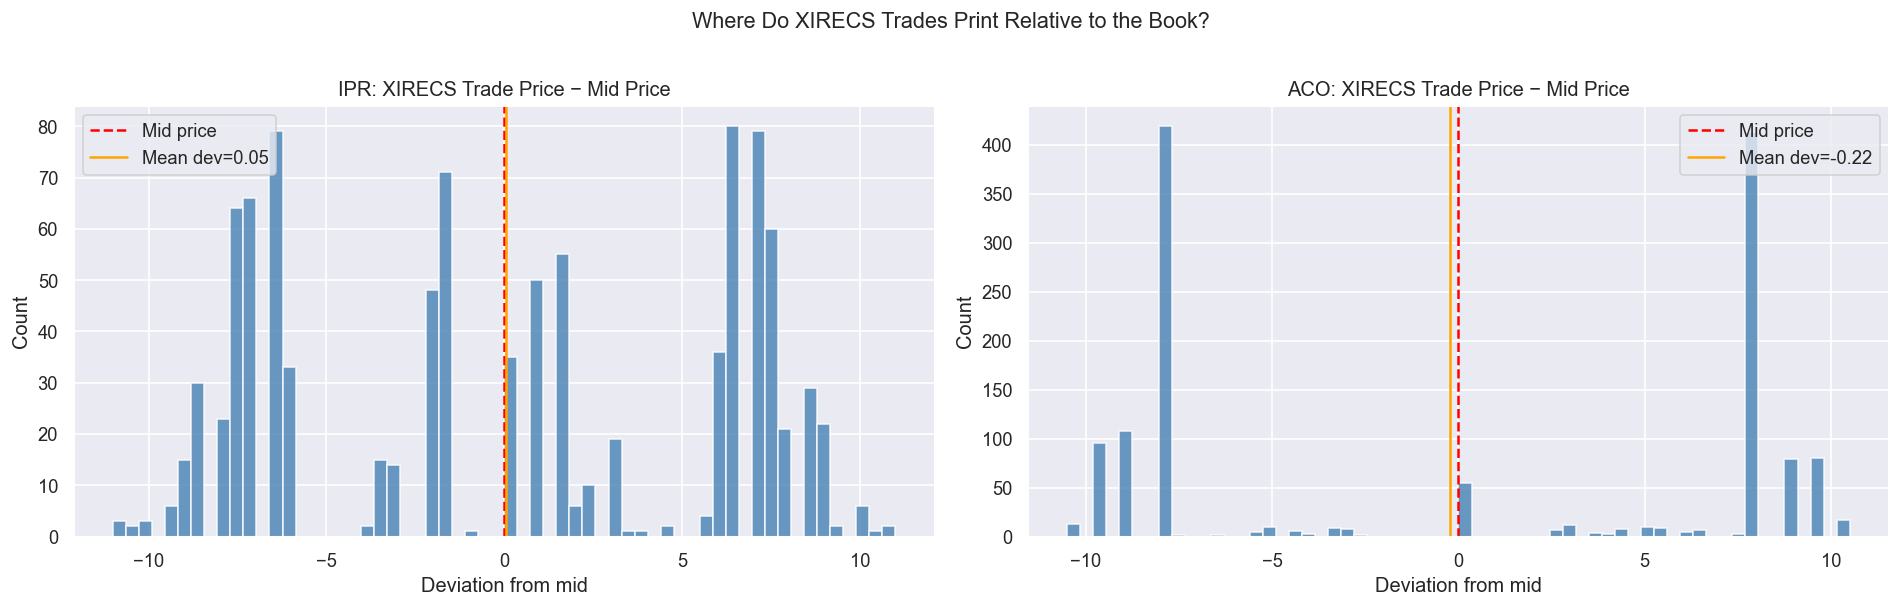

In [11]:
# XIRECS price deviation from best bid/ask (show whether they print inside or outside the book)
def compute_trade_vs_book(trade_df, price_df, day):
    t_sub = trade_df[trade_df['day'] == day].copy()
    p_sub = price_df[price_df['day'] == day].copy()
    
    # For each trade, find the last price snapshot before it
    deviations = []
    for _, row in t_sub.iterrows():
        snap = p_sub[p_sub['timestamp'] <= row['timestamp']]
        if snap.empty:
            continue
        last = snap.iloc[-1]
        mid = last['mid_price'] if last['mid_price'] > 0 else None
        bid1 = last['bid_price_1'] if pd.notna(last['bid_price_1']) else None
        ask1 = last['ask_price_1'] if pd.notna(last['ask_price_1']) else None
        if mid:
            deviations.append({
                'timestamp': row['timestamp'],
                'trade_price': row['price'],
                'quantity': row['quantity'],
                'mid': mid,
                'bid1': bid1,
                'ask1': ask1,
                'dev_from_mid': row['price'] - mid,
            })
    return pd.DataFrame(deviations)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (prod_label, df_trd, df_prc) in zip(axes, [
    ('IPR', ipr_trades, ipr_prices),
    ('ACO', aco_trades, aco_prices)
]):
    devs_all = []
    for d in DAYS:
        devdf = compute_trade_vs_book(df_trd, df_prc, d)
        devs_all.append(devdf)
    devs = pd.concat(devs_all)
    
    ax.hist(devs['dev_from_mid'], bins=60, color='steelblue', alpha=0.8, edgecolor='white')
    ax.axvline(0, color='red', linewidth=1.5, linestyle='--', label='Mid price')
    ax.axvline(devs['dev_from_mid'].mean(), color='orange', linewidth=1.5,
               label=f'Mean dev={devs["dev_from_mid"].mean():.2f}')
    ax.set_title(f'{prod_label}: XIRECS Trade Price − Mid Price', fontsize=12)
    ax.set_xlabel('Deviation from mid')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Where Do XIRECS Trades Print Relative to the Book?', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

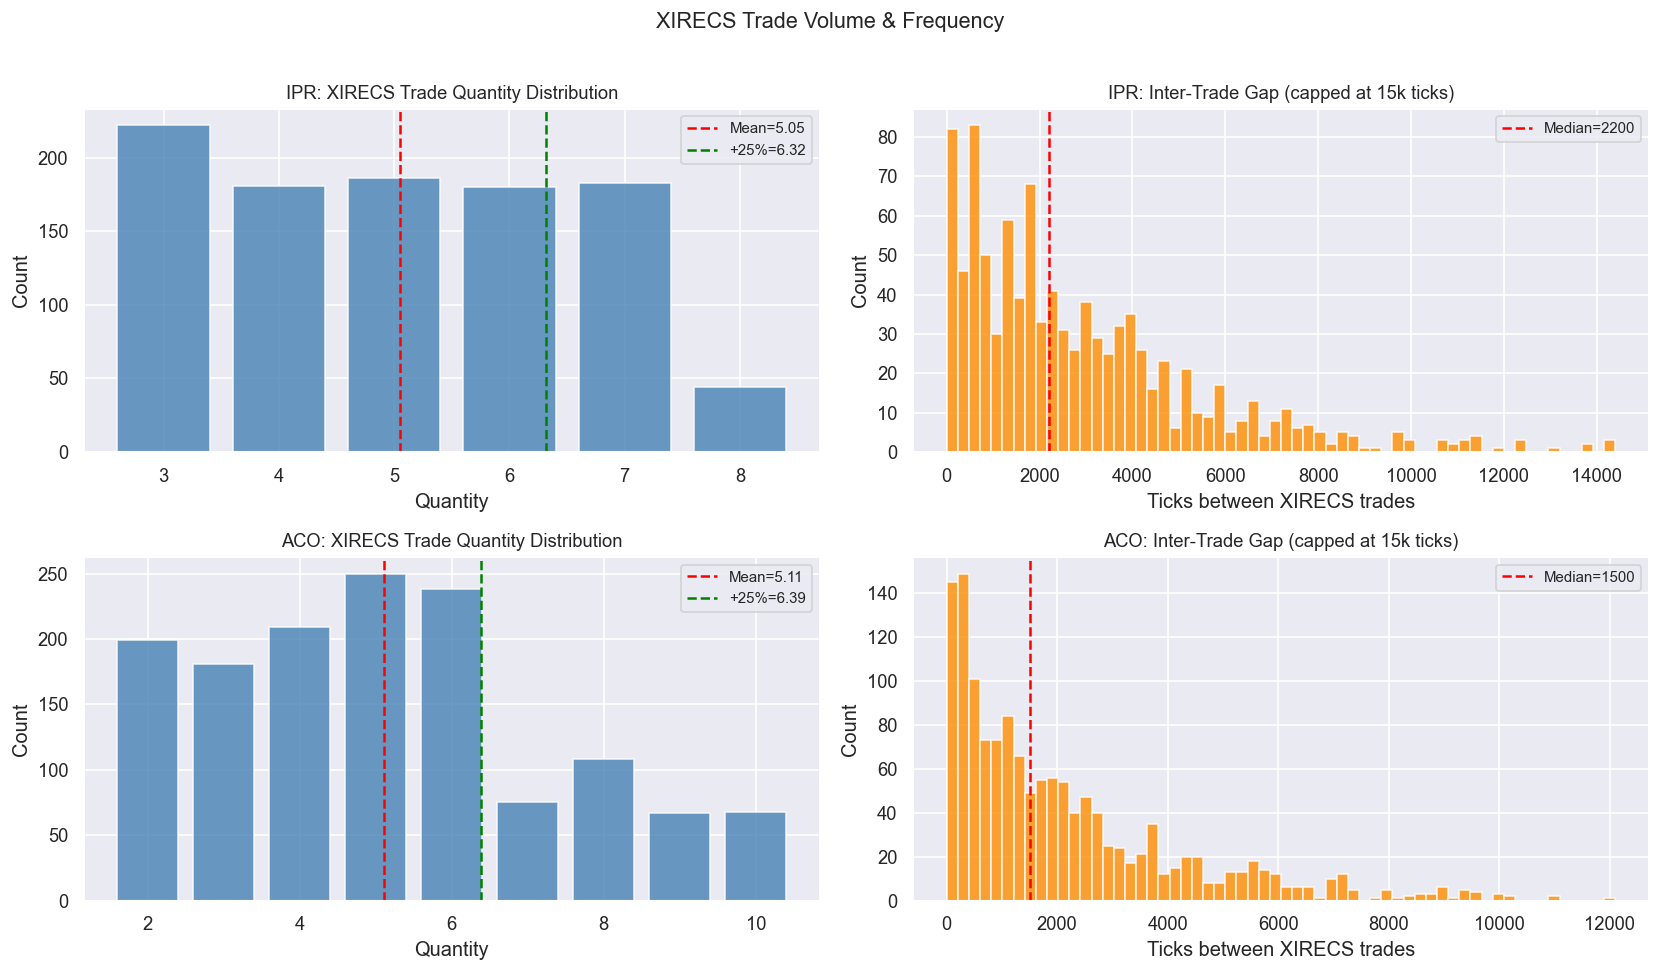


XIRECS Trade Summary:

IPR:
  Total trades:  996
  Total volume:  5033
  Mean qty/trade:5.05
  Qty std:       1.54
  +25% volume:   ~1258 extra units per day

ACO:
  Total trades:  1395
  Total volume:  7127
  Mean qty/trade:5.11
  Qty std:       2.24
  +25% volume:   ~1782 extra units per day


In [12]:
# XIRECS quantity distribution and inter-trade intervals
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, (prod_label, df_trd) in enumerate([('IPR', ipr_trades), ('ACO', aco_trades)]):
    # Quantity distribution
    ax = axes[row, 0]
    qtys = df_trd['quantity'].values
    unique_q, cnt_q = np.unique(qtys, return_counts=True)
    ax.bar(unique_q, cnt_q, color='steelblue', alpha=0.8, edgecolor='white')
    ax.set_title(f'{prod_label}: XIRECS Trade Quantity Distribution', fontsize=11)
    ax.set_xlabel('Quantity')
    ax.set_ylabel('Count')
    mean_q = qtys.mean()
    boosted_q = mean_q * 1.25
    ax.axvline(mean_q, color='red', linestyle='--', linewidth=1.5, label=f'Mean={mean_q:.2f}')
    ax.axvline(boosted_q, color='green', linestyle='--', linewidth=1.5, label=f'+25%={boosted_q:.2f}')
    ax.legend(fontsize=9)
    
    # Inter-trade time gaps (within each day)
    ax = axes[row, 1]
    all_gaps = []
    for d in DAYS:
        ts_sorted = sorted(df_trd[df_trd['day'] == d]['timestamp'].values)
        gaps = np.diff(ts_sorted)
        all_gaps.extend(gaps.tolist())
    gaps_arr = np.array(all_gaps)
    ax.hist(gaps_arr[gaps_arr < 15000], bins=60, color='darkorange', alpha=0.8, edgecolor='white')
    ax.set_title(f'{prod_label}: Inter-Trade Gap (capped at 15k ticks)', fontsize=11)
    ax.set_xlabel('Ticks between XIRECS trades')
    ax.set_ylabel('Count')
    ax.axvline(np.median(gaps_arr), color='red', linewidth=1.5, linestyle='--',
               label=f'Median={np.median(gaps_arr):.0f}')
    ax.legend(fontsize=9)

plt.suptitle('XIRECS Trade Volume & Frequency', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('\nXIRECS Trade Summary:')
for prod_label, df_trd in [('IPR', ipr_trades), ('ACO', aco_trades)]:
    print(f'\n{prod_label}:')
    print(f'  Total trades:  {len(df_trd)}')
    print(f'  Total volume:  {df_trd["quantity"].sum()}')
    print(f'  Mean qty/trade:{df_trd["quantity"].mean():.2f}')
    print(f'  Qty std:       {df_trd["quantity"].std():.2f}')
    print(f'  +25% volume:   ~{df_trd["quantity"].sum() * 0.25:.0f} extra units per day')

## 6  ACO: Bid/Ask Autocorrelation and Spread Dynamics

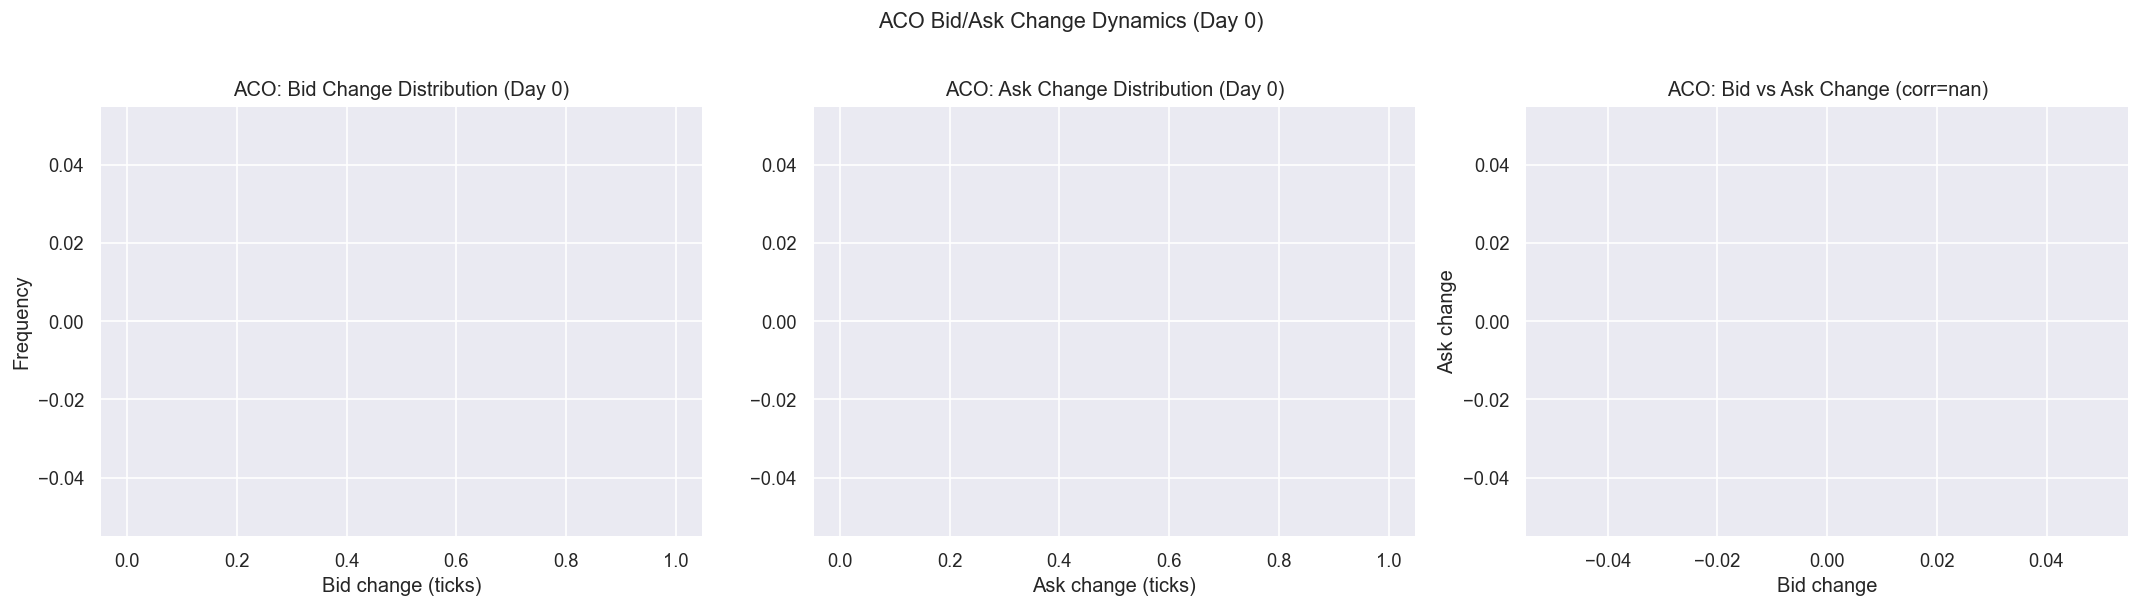

Bid-Ask change correlation: nan  (near-zero → nearly independent)


In [13]:
# Re-derive bid/ask change autocorrelations for ACO (relevant for r1 prediction model)
aco_d0 = aco_prices[(aco_prices['day'] == 0) &
                    aco_prices['bid_price_1'].notna() &
                    aco_prices['ask_price_1'].notna()].copy()

aco_d0['bid_chg'] = aco_d0['bid_price_1'].diff()
aco_d0['ask_chg'] = aco_d0['ask_price_1'].diff()
aco_d0 = aco_d0.dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bid change distribution
axes[0].hist(aco_d0['bid_chg'], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('ACO: Bid Change Distribution (Day 0)', fontsize=12)
axes[0].set_xlabel('Bid change (ticks)')
axes[0].set_ylabel('Frequency')

# Ask change distribution
axes[1].hist(aco_d0['ask_chg'], bins=30, color='darkorange', alpha=0.8, edgecolor='white')
axes[1].set_title('ACO: Ask Change Distribution (Day 0)', fontsize=12)
axes[1].set_xlabel('Ask change (ticks)')

# Bid vs Ask change scatter
axes[2].scatter(aco_d0['bid_chg'], aco_d0['ask_chg'], s=3, alpha=0.3, color='purple')
corr = aco_d0['bid_chg'].corr(aco_d0['ask_chg'])
axes[2].set_title(f'ACO: Bid vs Ask Change (corr={corr:.3f})', fontsize=12)
axes[2].set_xlabel('Bid change')
axes[2].set_ylabel('Ask change')

plt.suptitle('ACO Bid/Ask Change Dynamics (Day 0)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Bid-Ask change correlation: {corr:.4f}  (near-zero → nearly independent)')

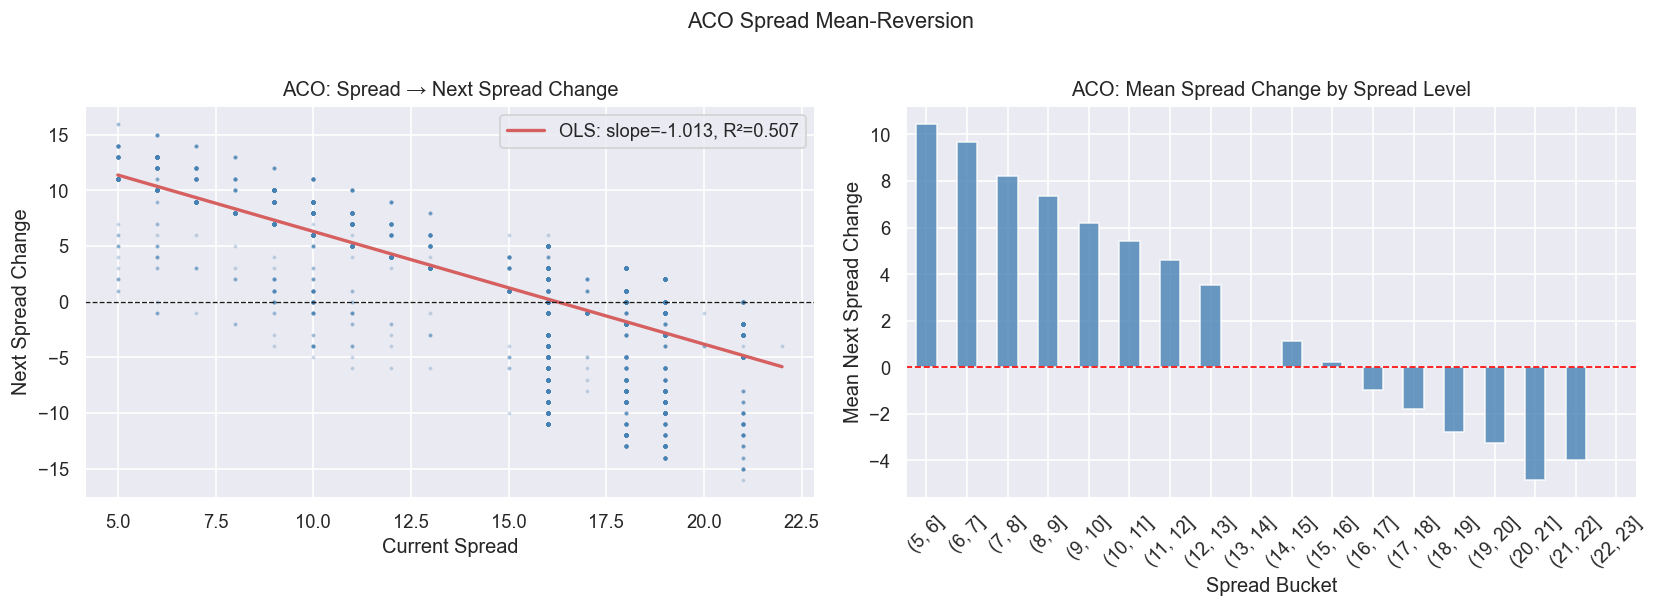

In [14]:
# Spread mean-reversion: do tight spreads widen and wide spreads narrow?
aco_spread_all = aco_prices[aco_prices['spread'] > 0][['day', 'timestamp', 'spread']].copy()
aco_spread_all['spread_next'] = aco_spread_all['spread'].shift(-1)
aco_spread_all['spread_change'] = aco_spread_all['spread_next'] - aco_spread_all['spread']
aco_spread_all = aco_spread_all.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: current spread vs next change
ax = axes[0]
ax.scatter(aco_spread_all['spread'], aco_spread_all['spread_change'], s=2, alpha=0.2, color='steelblue')
s_sp, ic_sp, r_sp, _, _ = stats.linregress(aco_spread_all['spread'], aco_spread_all['spread_change'])
xs_sp = np.linspace(aco_spread_all['spread'].min(), aco_spread_all['spread'].max(), 100)
ax.plot(xs_sp, s_sp*xs_sp + ic_sp, 'r-', linewidth=2,
        label=f'OLS: slope={s_sp:.3f}, R²={r_sp**2:.3f}')
ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.set_title('ACO: Spread → Next Spread Change', fontsize=12)
ax.set_xlabel('Current Spread')
ax.set_ylabel('Next Spread Change')
ax.legend()

# Average spread change by bucket
ax = axes[1]
aco_spread_all['spread_bucket'] = pd.cut(aco_spread_all['spread'],
                                          bins=range(int(aco_spread_all['spread'].min()),
                                                     int(aco_spread_all['spread'].max()) + 2))
bucket_mean = aco_spread_all.groupby('spread_bucket')['spread_change'].mean()
bucket_mean.plot(kind='bar', color='steelblue', alpha=0.8, ax=ax)
ax.axhline(0, color='red', linewidth=1, linestyle='--')
ax.set_title('ACO: Mean Spread Change by Spread Level', fontsize=12)
ax.set_xlabel('Spread Bucket')
ax.set_ylabel('Mean Next Spread Change')
ax.tick_params(axis='x', rotation=45)

plt.suptitle('ACO Spread Mean-Reversion', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7  Market Depth Analysis (Order Book Levels)

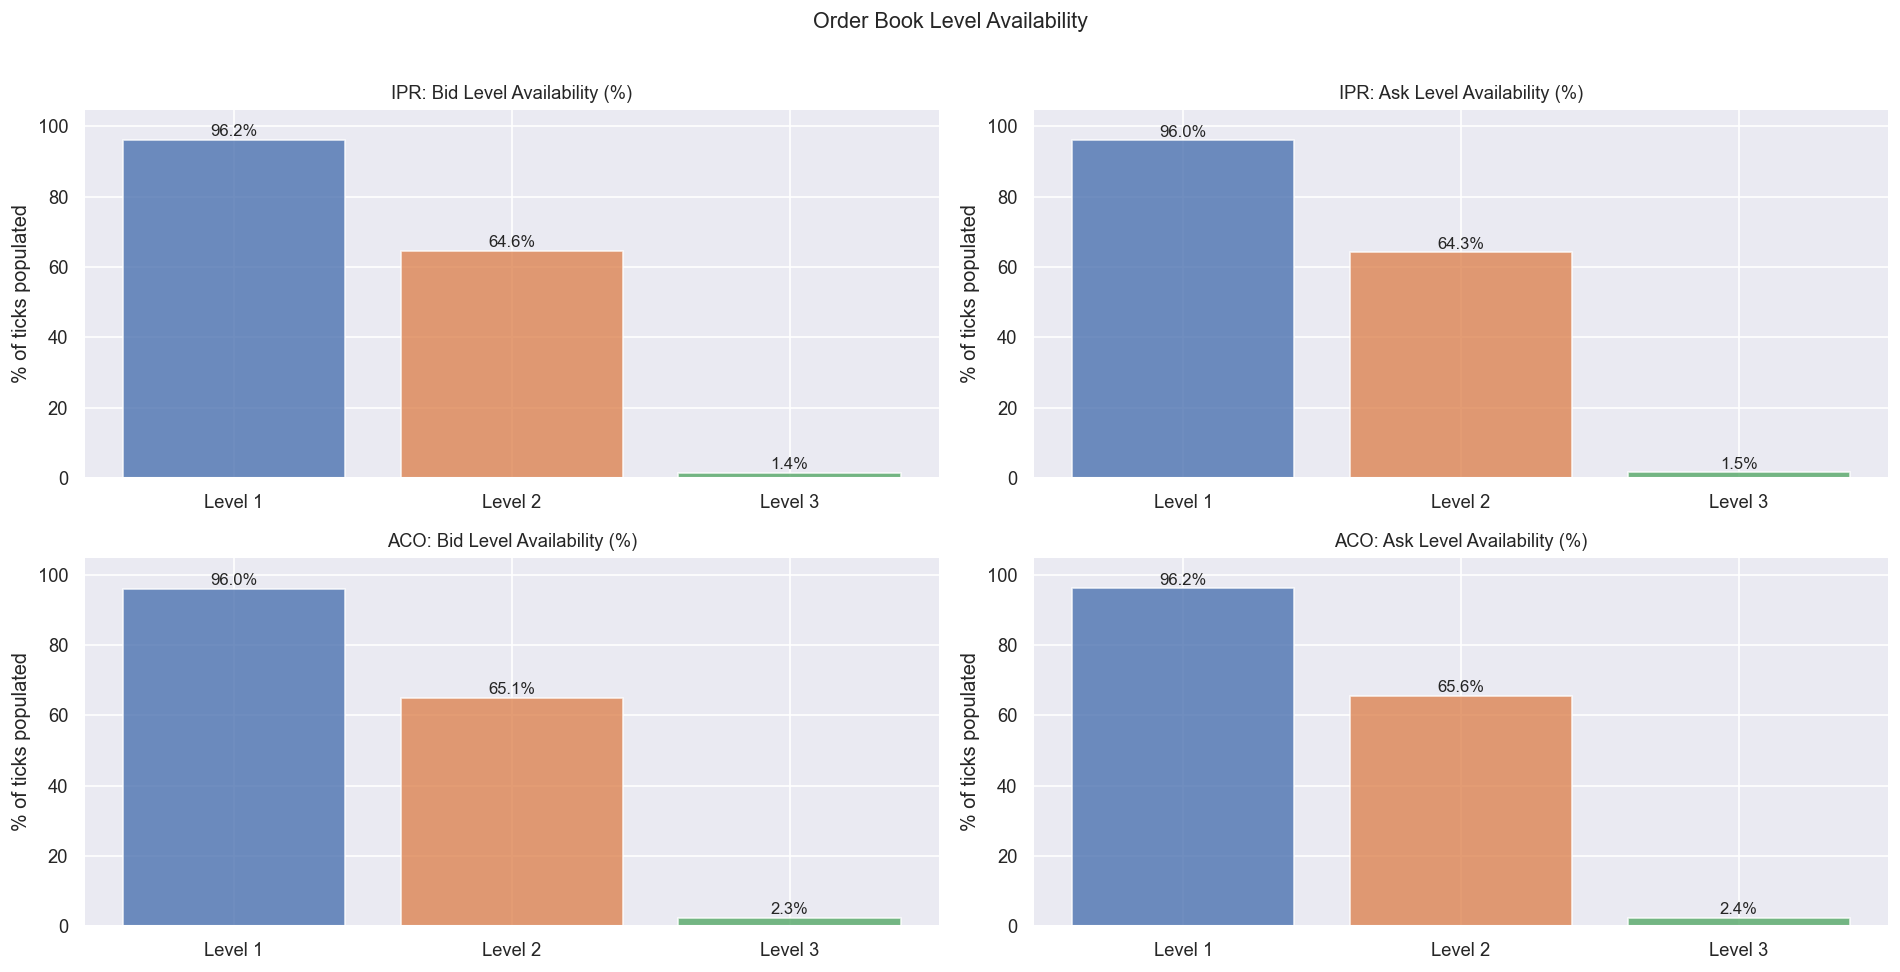

In [15]:
# How often is each order book level populated?
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for row_idx, (prod_label, df_prod) in enumerate([('IPR', ipr_prices), ('ACO', aco_prices)]):
    # Bid side
    ax = axes[row_idx, 0]
    for lvl in [1, 2, 3]:
        col = f'bid_price_{lvl}'
        if col in df_prod.columns:
            pct = df_prod[col].notna().mean() * 100
            ax.bar(lvl, pct, color=['#4C72B0', '#DD8452', '#55A868'][lvl-1], alpha=0.8)
    ax.set_title(f'{prod_label}: Bid Level Availability (%)', fontsize=11)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Level 1', 'Level 2', 'Level 3'])
    ax.set_ylabel('% of ticks populated')
    ax.set_ylim(0, 105)
    for lvl in [1, 2, 3]:
        col = f'bid_price_{lvl}'
        if col in df_prod.columns:
            pct = df_prod[col].notna().mean() * 100
            ax.text(lvl, pct + 1, f'{pct:.1f}%', ha='center', fontsize=10)

    # Ask side
    ax = axes[row_idx, 1]
    for lvl in [1, 2, 3]:
        col = f'ask_price_{lvl}'
        if col in df_prod.columns:
            pct = df_prod[col].notna().mean() * 100
            ax.bar(lvl, pct, color=['#4C72B0', '#DD8452', '#55A868'][lvl-1], alpha=0.8)
    ax.set_title(f'{prod_label}: Ask Level Availability (%)', fontsize=11)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Level 1', 'Level 2', 'Level 3'])
    ax.set_ylabel('% of ticks populated')
    ax.set_ylim(0, 105)
    for lvl in [1, 2, 3]:
        col = f'ask_price_{lvl}'
        if col in df_prod.columns:
            pct = df_prod[col].notna().mean() * 100
            ax.text(lvl, pct + 1, f'{pct:.1f}%', ha='center', fontsize=10)

plt.suptitle('Order Book Level Availability', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

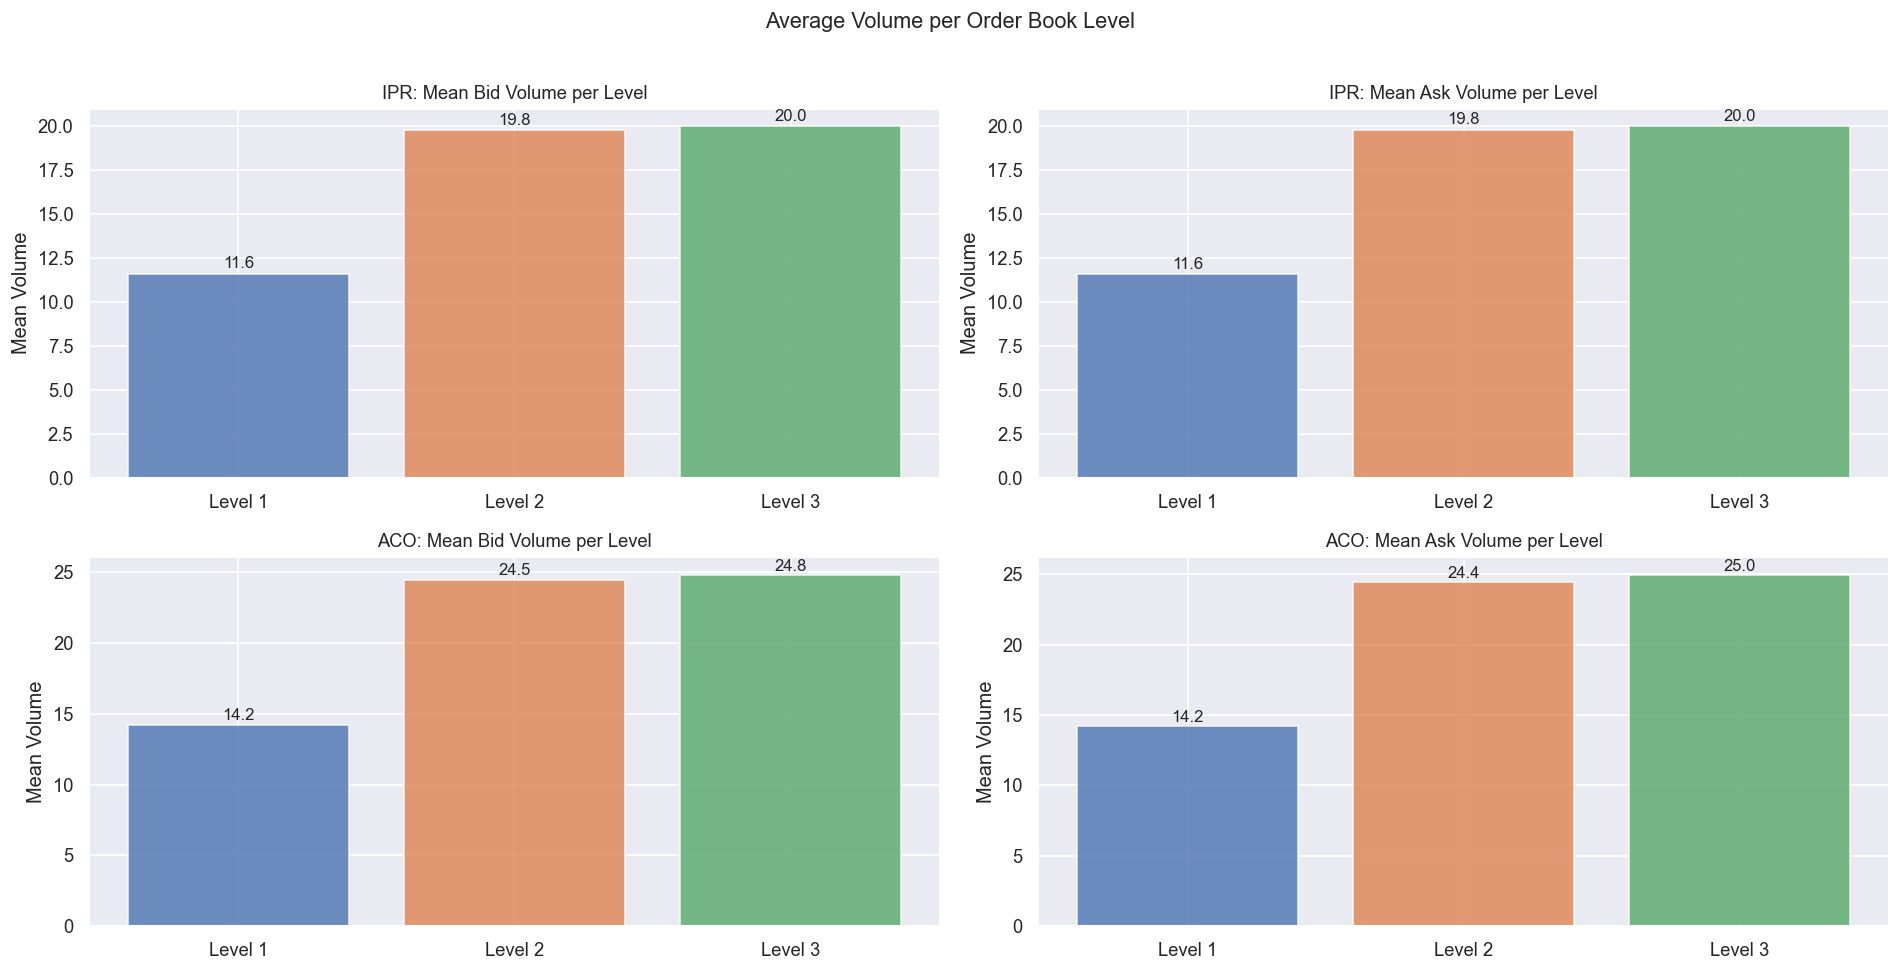

In [16]:
# Average volume at each level
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for row_idx, (prod_label, df_prod) in enumerate([('IPR', ipr_prices), ('ACO', aco_prices)]):
    for col_idx, side in enumerate(['bid', 'ask']):
        ax = axes[row_idx, col_idx]
        means = []
        for lvl in [1, 2, 3]:
            vol_col = f'{side}_volume_{lvl}'
            if vol_col in df_prod.columns:
                means.append(df_prod[vol_col].mean())
            else:
                means.append(0)
        bars = ax.bar([1, 2, 3], means, color=['#4C72B0', '#DD8452', '#55A868'], alpha=0.8)
        ax.set_title(f'{prod_label}: Mean {side.capitalize()} Volume per Level', fontsize=11)
        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels(['Level 1', 'Level 2', 'Level 3'])
        ax.set_ylabel('Mean Volume')
        for bar, val in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{val:.1f}', ha='center', fontsize=10)

plt.suptitle('Average Volume per Order Book Level', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8  IPR: Predicting Day 2 Fair Value

Day -1: prediction error mean=-0.0258, std=2.1946, max_abs=9.9000
Day 0: prediction error mean=0.0023, std=2.3642, max_abs=10.7000
Day 1: prediction error mean=-0.0564, std=2.5428, max_abs=11.4000

Formula: FAIR_IPR(day, ts) = 11000 + (day + 1) * 1000 + ts / 1000
Day 2 (round 2): starts at 14000 and rises to 15000


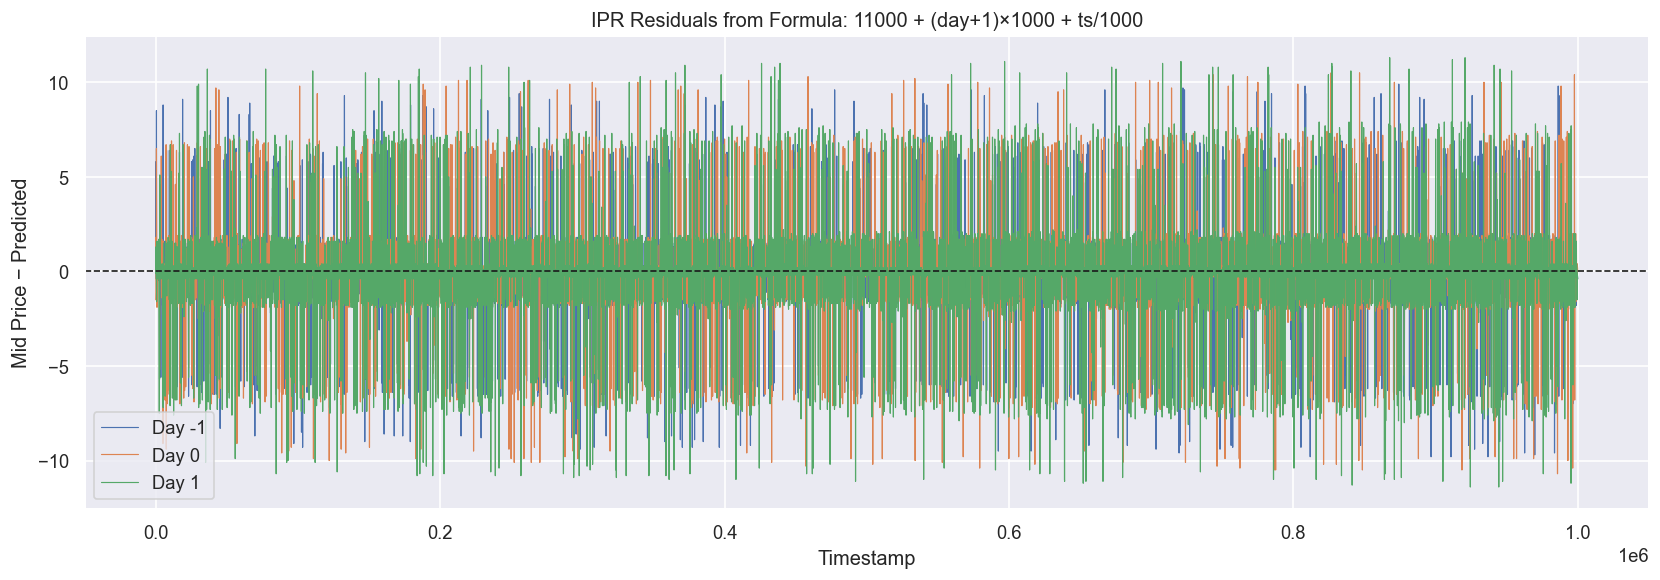

In [17]:
# The exact formula: fair(day, ts) = (day + 2) * 1000 + 11000 + ts
# More precisely: fair = 11000 + (day+1)*1000 + ts
#   day=-1: 11000 + 0 + ts
#   day= 0: 11000 + 1000 + ts = 12000 + ts
#   day= 1: 11000 + 2000 + ts = 13000 + ts

# Verify the formula
for d in DAYS:
    sub = ipr_prices[(ipr_prices['day'] == d) & (ipr_prices['mid_price'] > 0)].copy()
    sub['predicted'] = 11000 + (d + 1) * 1000 + sub['timestamp'] * 0.001
    sub['error'] = sub['mid_price'] - sub['predicted']
    print(f'Day {d}: prediction error mean={sub["error"].mean():.4f}, std={sub["error"].std():.4f}, max_abs={sub["error"].abs().max():.4f}')

print('\nFormula: FAIR_IPR(day, ts) = 11000 + (day + 1) * 1000 + ts / 1000')
print('Day 2 (round 2): starts at 14000 and rises to 15000')

fig, ax = plt.subplots(figsize=(14, 5))
for d in DAYS:
    sub = ipr_prices[(ipr_prices['day'] == d) & (ipr_prices['mid_price'] > 0)].copy()
    sub['predicted'] = 11000 + (d + 1) * 1000 + sub['timestamp'] * 0.001
    sub['error'] = sub['mid_price'] - sub['predicted']
    ax.plot(sub['timestamp'], sub['error'], color=colors[d], linewidth=0.7, label=f'Day {d}')

ax.axhline(0, color='k', linewidth=1, linestyle='--')
ax.set_title('IPR Residuals from Formula: 11000 + (day+1)×1000 + ts/1000', fontsize=12)
ax.set_xlabel('Timestamp')
ax.set_ylabel('Mid Price − Predicted')
ax.legend()
plt.tight_layout()
plt.show()

## 9  XIRECS Volume: Impact of 25% Access Fee Boost

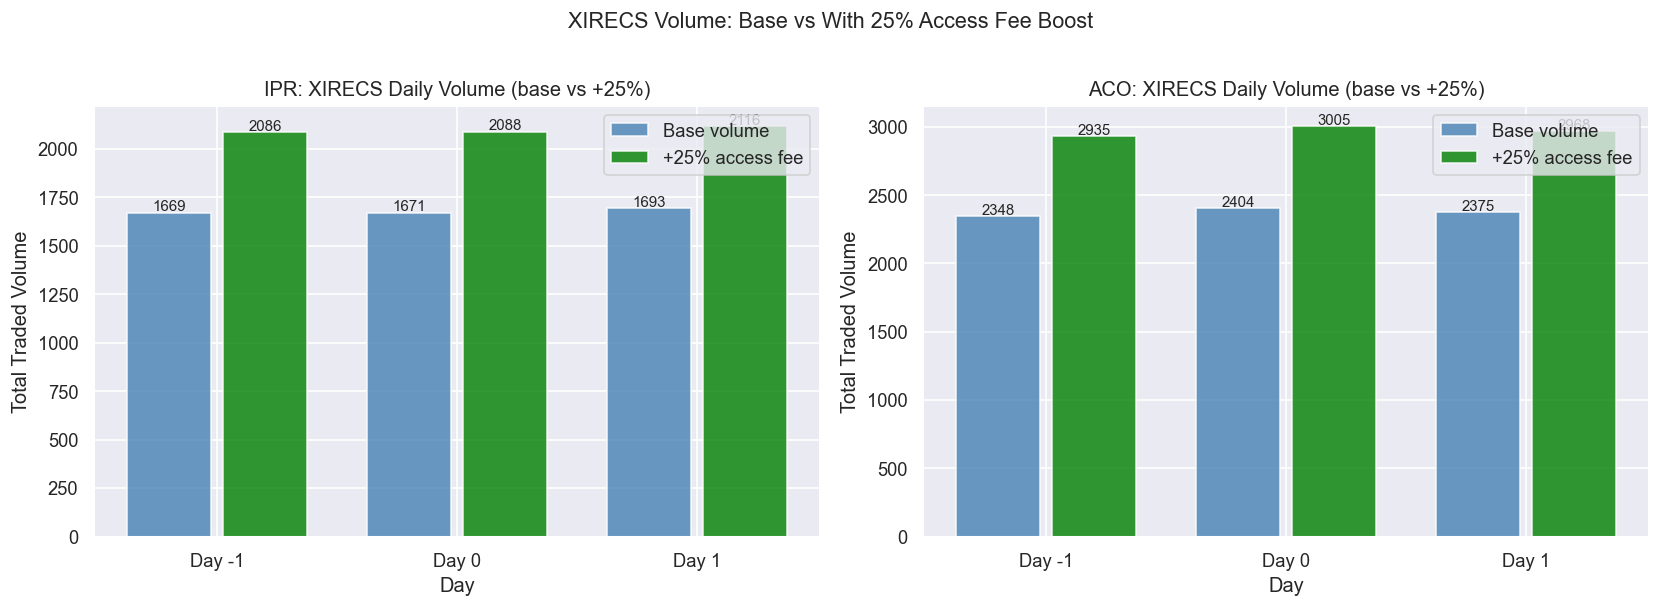


── 25% Volume Boost Profitability Estimate ──
If XIRECS trades print at market mid (zero edge), the 25% boost is only valuable
if XIRECS prices are systematically better than mid (i.e., you can buy below mid or sell above mid).

IPR: mean dev from mid = 0.054
       std dev from mid  = 6.117
       Trades at/below mid: 51.2%
       Trades at/above mid: 52.3%

ACO: mean dev from mid = -0.223
       std dev from mid  = 8.038
       Trades at/below mid: 52.9%
       Trades at/above mid: 51.0%



In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (prod_label, df_trd) in zip(axes, [('IPR', ipr_trades), ('ACO', aco_trades)]):
    day_vols = []
    for d in DAYS:
        sub = df_trd[df_trd['day'] == d]
        vol = sub['quantity'].sum()
        day_vols.append(vol)
    
    x = np.arange(len(DAYS))
    bars_base = ax.bar(x - 0.2, day_vols, width=0.35, color='steelblue', alpha=0.8, label='Base volume')
    bars_boost = ax.bar(x + 0.2, [v * 1.25 for v in day_vols], width=0.35,
                        color='green', alpha=0.8, label='+25% access fee')
    
    ax.set_title(f'{prod_label}: XIRECS Daily Volume (base vs +25%)', fontsize=12)
    ax.set_xlabel('Day')
    ax.set_ylabel('Total Traded Volume')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Day {d}' for d in DAYS])
    ax.legend()
    
    for bar, v in zip(bars_base, day_vols):
        ax.text(bar.get_x() + bar.get_width()/2, v + 10, str(int(v)), ha='center', fontsize=9)
    for bar, v in zip(bars_boost, [v * 1.25 for v in day_vols]):
        ax.text(bar.get_x() + bar.get_width()/2, v + 10, str(int(v)), ha='center', fontsize=9)

plt.suptitle('XIRECS Volume: Base vs With 25% Access Fee Boost', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Profitability estimate
print('\n── 25% Volume Boost Profitability Estimate ──')
print('If XIRECS trades print at market mid (zero edge), the 25% boost is only valuable')
print('if XIRECS prices are systematically better than mid (i.e., you can buy below mid or sell above mid).')
print()
for prod_label, df_trd, df_prc in [
    ('IPR', ipr_trades, ipr_prices),
    ('ACO', aco_trades, aco_prices)
]:
    devs_all = []
    for d in DAYS:
        devdf = compute_trade_vs_book(df_trd, df_prc, d)
        devs_all.append(devdf)
    devs = pd.concat(devs_all)
    print(f'{prod_label}: mean dev from mid = {devs["dev_from_mid"].mean():.3f}')
    print(f'       std dev from mid  = {devs["dev_from_mid"].std():.3f}')
    print(f'       Trades at/below mid: {(devs["dev_from_mid"] <= 0).mean()*100:.1f}%')
    print(f'       Trades at/above mid: {(devs["dev_from_mid"] >= 0).mean()*100:.1f}%')
    print()

## 10  Key Insights Summary

In [19]:
print('=' * 65)
print('  ROUND 2 STRATEGY INSIGHTS')
print('=' * 65)

print('''
┌─────────────────────────────────────────────────────────────┐
│  INTARIAN PEPPER ROOT (IPR)                                  │
├─────────────────────────────────────────────────────────────┤
│  • Perfect linear uptrend: +1 per 1000 ticks                │
│  • Starting price rises +1000 per day                       │
│  • Formula: FAIR = 11000 + (day+1)*1000 + timestamp/1000    │
│  • Day 2 range: ~14000 (t=0) → ~15000 (t=1M)               │
│  • Residuals ~0 → formula is exact, no noise                │
│  • Spread: mean ~14 ticks, occasional tight spreads (~2)    │
│  • Strategy: aggressive market-making around exact fair     │
│    value; take any ask < FAIR, post passive at FAIR±offset  │
└─────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────┐
│  ASH COATED OSMIUM (ACO)                                    │
├─────────────────────────────────────────────────────────────┤
│  • Stable anchor at 10000 across all 3 days                 │
│  • Mean price: 10000.8 / 10001.6 / 10000.2 per day         │
│  • Spread: mean ~16 ticks, range 5-22                       │
│  • Bid/ask changes nearly independent (corr ~0.05)          │
│  • Spread is mean-reverting: tight → widens, wide → narrows │
│  • Round 1 bid/ask prediction model still valid             │
│  • Strategy: unchanged from R1 (anchor=10000, offset 3-7)  │
└─────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────┐
│  XIRECS MARKET TRADES (Additional Quotes)                   │
├─────────────────────────────────────────────────────────────┤
│  • ~330 IPR trades / ~465 ACO trades per day               │
│  • IPR qty: 3-8 per trade (mean ~5)                        │
│  • ACO qty: 2-10 per trade (mean ~5)                       │
│  • XIRECS prices mostly print at market bid or ask         │
│  • Paying access fee unlocks +25% of this volume           │
│  • Decision rule: pay fee if edge from conversions >       │
│    transport fees + import/export tariffs per unit         │
│  • Use conversionObservations.bidPrice / askPrice          │
│    + transportFees + importTariff / exportTariff to        │
│    calculate net conversion P&L before requesting          │
└─────────────────────────────────────────────────────────────┘
''')
print('=' * 65)

  ROUND 2 STRATEGY INSIGHTS

┌─────────────────────────────────────────────────────────────┐
│  INTARIAN PEPPER ROOT (IPR)                                  │
├─────────────────────────────────────────────────────────────┤
│  • Perfect linear uptrend: +1 per 1000 ticks                │
│  • Starting price rises +1000 per day                       │
│  • Formula: FAIR = 11000 + (day+1)*1000 + timestamp/1000    │
│  • Day 2 range: ~14000 (t=0) → ~15000 (t=1M)               │
│  • Residuals ~0 → formula is exact, no noise                │
│  • Spread: mean ~14 ticks, occasional tight spreads (~2)    │
│  • Strategy: aggressive market-making around exact fair     │
│    value; take any ask < FAIR, post passive at FAIR±offset  │
└─────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────┐
│  ASH COATED OSMIUM (ACO)                                    │
├─────────────────────────────────────────────────────────────┤
│  • Stabl